# Banco de Ejercicios - Analisis Numerico (otro_tema)

Este cuaderno propone ejercicios de estudio basados en los temas trabajados en la carpeta `otro_tema`.

> Puedes importar y usar libremente funciones de `sel.py` y `modelos.py` en todos los puntos.

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

import sel as sl
import modelos as md
import ceros as cz

x = sp.symbols('x')

## 1) Sistemas de Ecuaciones Lineales

### Ejercicio 1.1 - Eliminacion sin pivote y con pivote
Resuelve el sistema y compara con `numpy.linalg.solve`.

$$
\begin{cases}
2x_1 - x_2 + x_3 = 1 \\
4x_1 + x_2 - 2x_3 = 2 \\
-2x_1 + 2x_2 + 3x_3 = 0
\end{cases}
$$

1. Resuelve con `sl.eliminacion_DD(A,b)`.
2. Intenta resolver con `sl.Eliminacion_con_pivote(A,b)`.
3. Calcula el error infinito respecto a la solucion exacta.

### Ejercicio 1.2 - Diagnostico de convergencia
Para
$$A=\begin{bmatrix}1&3&-2\\4&1&1\\2&-1&5\end{bmatrix}$$
evalua si Jacobi y Gauss-Seidel convergen usando el radio espectral de sus matrices de iteracion.]

### Ejercicio 1.3 - Jacobi vs Gauss-Seidel
Con
$$A=\begin{bmatrix}10&-3&5\\-2&-13&7\\4&-8&15\end{bmatrix},\; b=\begin{bmatrix}12\\23\\14\end{bmatrix}$$
haz:
1. `sl.Jacobi_matrices` y `sl.Jacobi_sumas` con el mismo `x0` y tolerancia.
2. `sl.gauss_seidel_matrices` y `sl.Gauss_seidel_sumas` con el mismo `x0` y tolerancia.
3. Tabla comparativa: iteraciones, tiempo, error final.

## 2) Interpolacion Polinomial y Lagrange

### Ejercicio 2.1 - Interpolacion polinomial simple
Datos de crecimiento (dias, mg):

| dia | 0 | 6 | 10 | 13 | 17 | 20 | 28 |
|---|---:|---:|---:|---:|---:|---:|---:|
| peso | 6.67 | 17.33 | 42.67 | 37.33 | 30.10 | 29.31 | 28.74 |

1. Construye `A = md.Matrix(dias)`.
2. Obtiene coeficientes con `sl.eliminacion_DD(A, peso)`.
3. Forma el polinomio y aproxima el peso en dia 4, 11 y 25.
4. Grafica datos vs polinomio.



### Ejercicio 2.2 - Lagrange y validacion
Con los datos
$$(0,1.00000),\;(0.6,1.264911),\;(0.9,1.378404)$$
haz:
1. `P_L(x)` con `md.lagrange`.
2. Aproxima `f(0.45)` y calcula error absoluto contra `1.204158`.
3. Repite usando `md.polinomial_simple` y compara resultados.

1.2034238750000001
0.0007341249999999189


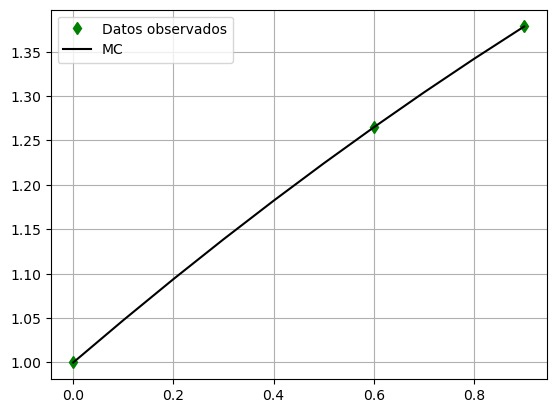

In [28]:
# Lagrange
x_data = np.array([0, 0.6, 0.9])
y_data = np.array([1.00000, 1.264911, 1.378404])
P = md.lagrange(x_data, y_data)
P = sp.lambdify(x, P)
x_values = np.linspace(min(x_data), max(x_data), 10)
plt.plot(x_data, y_data, 'gd', label='Datos observados')
plt.plot(x_values, P(x_values), 'k', label='MC')
plt.legend()
plt.grid()
r_aprox = P(0.45)
print(r_aprox)
error = abs(1.204158-r_aprox)
print(error)

1.203423875
0.0007341250000001409


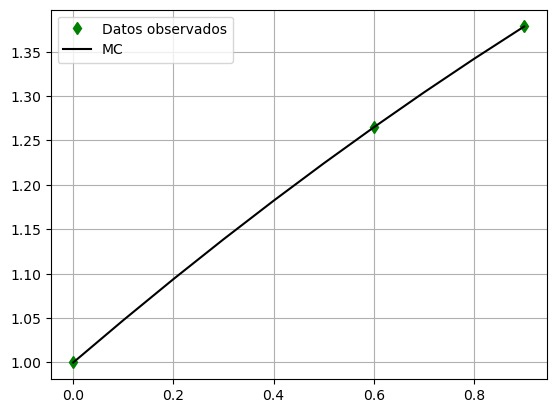

In [27]:
# Polinomial simple
x_data = np.array([0, 0.6, 0.9])
y_data = np.array([1.00000, 1.264911, 1.378404])
P = md.polinomial_simple(x_data, y_data)
P = sp.lambdify(x, P)
x_values = np.linspace(min(x_data), max(x_data), 10)
plt.plot(x_data, y_data, 'gd', label='Datos observados')
plt.plot(x_values, P(x_values), 'k', label='MC')
plt.legend()
plt.grid()
r_aprox = P(0.45)
print(r_aprox)
error = abs(1.204158-r_aprox)
print(error)

### Ejercicio 2.3 - Cero de un polinomio interpolante
Usa los datos:

| x | 0 | 0.5 | 1 | 1.5 | 2 | 2.5 | 3 |
|---|---:|---:|---:|---:|---:|---:|---:|
| y | 1.8421 | 2.4694 | 2.4921 | 1.9047 | 0.8509 | -0.4112 | -1.5727 |

1. Construye un polinomio con 3 nodos cercanos al cambio de signo.
2. Construye otro con 4 nodos cercanos.
3. Halla una aproximacion de la raiz con `cz.Newton(P, semilla, tol)` en ambos casos.
4. Compara estabilidad y sensibilidad de la raiz.

-0.9328*x**2 + 1.1572*x + 2.2677


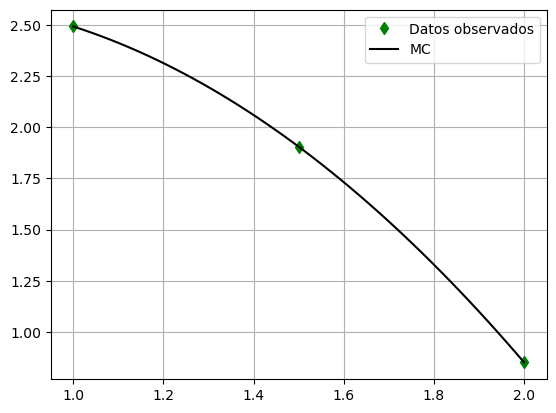

In [29]:
# x_data = np.array([0 , 0.5 , 1 , 1.5 , 2 , 2.5 , 3], float)
# y_data = np.array([1.8421 , 2.4694 , 2.4921 , 1.9047 , 0.8509 , -0.4112 , -1.5727], float)

# 1
x_data = np.array([1 , 1.5 , 2], float)
y_data = np.array([2.4921 , 1.9047 , 0.8509], float)
P = md.polinomial_simple(x_data, y_data)
P = sp.lambdify(x, P)
x_values = np.linspace(min(x_data), max(x_data), 50)
plt.plot(x_data, y_data, 'gd', label='Datos observados')
plt.plot(x_values, P(x_values), 'k', label='MC')
plt.legend()
plt.grid()

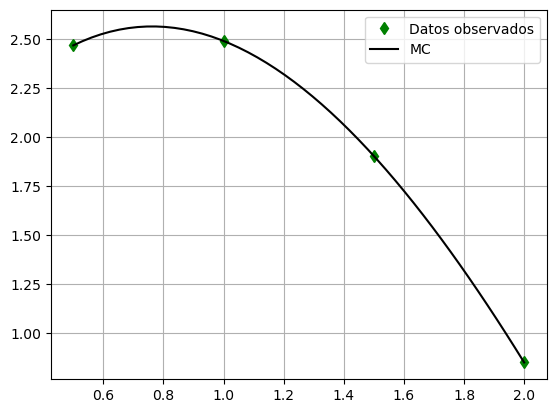

In [26]:
# 2
x_data = np.array([0.5 , 1 , 1.5 , 2], float)
y_data = np.array([2.4694 , 2.4921 , 1.9047 , 0.8509], float)
P = md.polinomial_simple(x_data, y_data)
P = sp.lambdify(x, P)
x_values = np.linspace(min(x_data), max(x_data), 50)
plt.plot(x_data, y_data, 'gd', label='Datos observados')
plt.plot(x_values, P(x_values), 'k', label='MC')
plt.legend()
plt.grid()

2.338695622932604

2.338695622932604

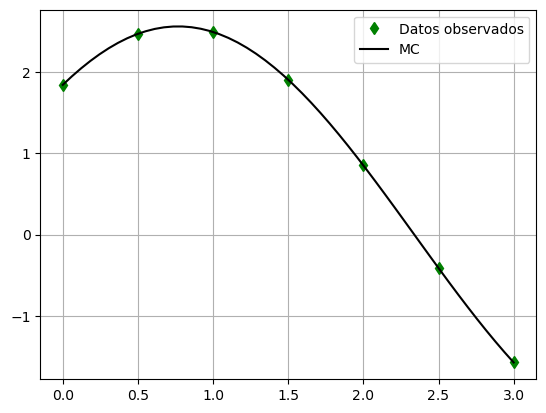

In [57]:
# 3
x_data = np.array([0 , 0.5 , 1 , 1.5 , 2 , 2.5 , 3], float)
y_data = np.array([1.8421 , 2.4694 , 2.4921 , 1.9047 , 0.8509 , -0.4112 , -1.5727], float)
P_s = md.polinomial_simple(x_data, y_data)
P = sp.lambdify(x, P_s)
x_values = np.linspace(min(x_data), max(x_data), 50)
plt.plot(x_data, y_data, 'gd', label='Datos observados')
plt.plot(x_values, P(x_values), 'k', label='MC')
plt.legend()
plt.grid()
cz.Newton(P_s, 2.25, 1e-6)

## 3) Regresion por Minimos Cuadrados

### Ejercicio 3.1 - Modelo lineal y prediccion
Usa los datos de densidad relativa del aire:

| h (km) | 0 | 1.525 | 3.050 | 4.575 | 6.10 | 7.625 | 9.150 |
|---|---:|---:|---:|---:|---:|---:|---:|
| rho | 1 | 0.8617 | 0.7385 | 0.6292 | 0.5238 | 0.4481 | 0.3741 |

1. Calcula `(m,b)` con `md.minimos_cuadrados`.
2. Estima `rho(1.5)` y `rho(8.0)`.
3. Calcula el RMSE del ajuste lineal.
4. Grafica datos y recta.

-0.06837470725995314 0.9664428571428568
0.8638807962529271
0.41944519906323174


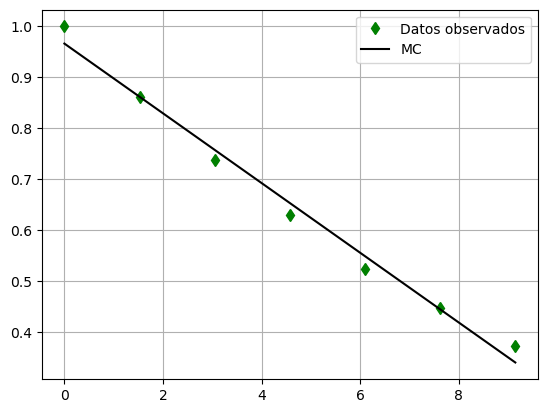

In [65]:
x_data = np.array([0 , 1.525 , 3.050 , 4.575 , 6.10 , 7.625 , 9.150], float)
y_data = np.array([1 , 0.8617 , 0.7385 , 0.6292 , 0.5238 , 0.4481 , 0.3741], float)
m, b = md.minimos_cuadrados(x_data, y_data)
print(m,b)
P = lambda x: m*x+b
x_values = np.linspace(min(x_data), max(x_data), 10)
plt.plot(x_data, y_data, 'gd', label='Datos observados')
plt.plot(x_values, P(x_values), 'k', label='MC')
plt.legend()
plt.grid()
print(P(1.5))
print(P(8.0))

### Ejercicio 3.2 - Interpolacion vs regresion
Con los datos del ejercicio de pinos (diametro-volumen):
1. Construye modelo interpolante de grado maximo y estima `P(18)`, `P(28)`.
2. Construye modelo lineal por minimos cuadrados y estima `P(18)`, `P(28)`.
3. Interpreta cual modelo usarias para extrapolar y por que.

## 4) Aplicacion: Placa de Temperatura (malla discreta)

### Ejercicio 4.1 - Sistema para nodos interiores
Construye un sistema lineal para una malla interior 3x3 (9 nodos) con fronteras fijas y resuelvelo con:
1. Eliminacion gaussiana.
2. Jacobi.
3. Gauss-Seidel.

Compara tiempos, iteraciones y error relativo.


### Ejercicio 4.2 - Analisis de condiciones de frontera
Modifica solo una frontera (por ejemplo, borde superior) y explica como cambia la distribucion de temperatura interior.

## 5) Simulacro de Parcial (90 minutos)

1. Resolver un sistema 4x4 por `sl.eliminacion_DD` y verificar con `numpy.linalg.solve`.
2. Evaluar convergencia de Jacobi y Gauss-Seidel por radio espectral.
3. Construir `P(x)` por Lagrange con 4 puntos y aproximar un valor intermedio.
4. Ajustar una recta por `md.minimos_cuadrados` y reportar predicciones en 2 puntos.
5. Pregunta conceptual: cuando prefieres interpolacion y cuando regresion?

### Criterio de autoevaluacion
- Correctitud numerica (40%)
- Procedimiento y justificacion (30%)
- Interpretacion de resultados (20%)
- Presentacion grafica y orden (10%)